In [2]:
import pandas as pd
import numpy as np
import warnings
from Bivariate import Bivariate
warnings.filterwarnings("ignore")

dataset = pd.read_csv("placement_1.csv")

dataset.drop('sl_no',inplace=True, axis=1)

quan, qual = Bivariate.quanQual(dataset)

dataset.isna().sum()

gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [4]:
# All Not placed students salary are null, so replace it by zero
dataset['salary'].fillna(0, inplace=True)
dataset.isna().sum()

gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

### 2)How many of them are not placed?

In [17]:
print(f'Number of students not placed: {dataset[dataset['status']=='Not Placed'].shape[0]}')

Number of students not placed: 67


### 3)Find the reason for non placement from the dataset?

#### Checking the Specialization details for Placed vs not placed students

In [40]:
dataset[dataset['status']=='Placed']['specialisation'].value_counts()

specialisation
Mkt&Fin    95
Mkt&HR     53
Name: count, dtype: int64

In [41]:
dataset[dataset['status']=='Not Placed']['specialisation'].value_counts()

specialisation
Mkt&HR     42
Mkt&Fin    25
Name: count, dtype: int64

##### The placement rate is high for Mkt&Fin Specialisation compared to Mkt&HR

#### To Statistically confirm performing chi-squared test. Since both are Categorical columns and test is based on counts

In [42]:
import pandas as pd
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(dataset['specialisation'], dataset['status'])
print("Contingency Table:")
print(contingency_table)

# Perform Chi-square test
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square Statistic: {chi2:.3f}")
print(f"P-value: {p_val:.3f}")
print(f"Degrees of Freedom: {dof}")
print("\nExpected Frequencies:")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

# Interpretation
if p_val < 0.05:
    print("\nReject H0: Specialisation and placement status are dependent.")
else:
    print("\nFail to reject H0: No significant association between specialisation and placement status.")


Contingency Table:
status          Not Placed  Placed
specialisation                    
Mkt&Fin                 25      95
Mkt&HR                  42      53

Chi-square Statistic: 12.440
P-value: 0.000
Degrees of Freedom: 1

Expected Frequencies:
status          Not Placed     Placed
specialisation                       
Mkt&Fin          37.395349  82.604651
Mkt&HR           29.604651  65.395349

Reject H0: Specialisation and placement status are dependent.


##### Using Chi-squared test, it is statistically proven that both Placement status and Specialization are dependent.

#### Comparing the Degree scores of placed vs not placed using T-test

In [32]:
# Perform T-test for degree_p for placed vs not placed

placed_degree_p = dataset[dataset['status']=='Placed']['degree_p']
notplaced_degree_p = dataset[dataset['status']=='Not Placed']['degree_p']

from scipy import stats

t_stat, p_val = stats.ttest_ind(placed_degree_p, notplaced_degree_p)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val}")
print(f"Placed degree score :{placed_degree_p.mean()}")
print(f"Not Placed degree score :{notplaced_degree_p.mean()}")

if p_val < 0.05:
    print("Reject H0: Average degree score of placed is significantly different from not placed.")
else:
    print("Fail to reject H0: No significant difference in degree score of placed and not placed.")

T-statistic: 7.982
P-value: 8.807682138862608e-14
Placed degree score :68.74054054054054
Not Placed degree score :61.13417910447761
Reject H0: Average degree score of placed is significantly different from not placed.


#### Degree scores of Placed is significantly higher than not placed and its statistically proven

#### Performing the same for mba scores

In [33]:
placed_mba_p = dataset[dataset['status']=='Placed']['mba_p']
notplaced_mba_p = dataset[dataset['status']=='Not Placed']['mba_p']

t_stat, p_val = stats.ttest_ind(placed_mba_p, notplaced_mba_p)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val}")
print(f"Placed degree score :{placed_mba_p.mean()}")
print(f"Not Placed degree score :{notplaced_mba_p.mean()}")

if p_val < 0.05:
    print("Reject H0: Average mba score of placed is significantly different from not placed.")
else:
    print("Fail to reject H0: No significant difference in mba score of placed and not placed.")

T-statistic: 1.126
P-value: 0.26144500197748627
Placed degree score :62.579391891891895
Not Placed degree score :61.612835820895526
Fail to reject H0: No significant difference in mba score of placed and not placed.


#### but mba scores are not significantly different P-value > 0.05

### Conclusion : Placement is based on the Specialisation done on MBA and its rate is quite high for "Mkt&Fin", Then the students who scored well in Degree are quite likely to be placed

### 4)What kind of relation between salary and mba_p

In [46]:
dataset[['mba_p','salary']].corr()

,mba_p,salary
mba_p,1.000000,0.139823
salary,0.139823,1.000000


In [47]:
dataset[['mba_p','salary']].cov()

,mba_p,salary
mba_p,34.028376,1.262455e+05
salary,126245.485547,2.395714e+10


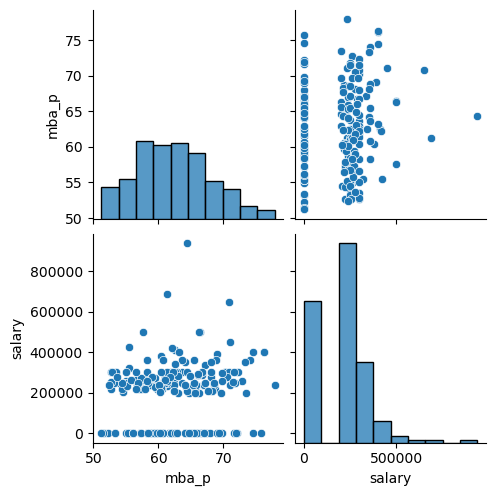

In [48]:
import seaborn as sns

sns.pairplot(dataset[['mba_p','salary']])

#### Correlation ≈ 0.14 → very weak positive correlation.

#### Scatter plot shows no strong linear trend.

### 5)Which specialization is getting minimum salary?

In [49]:
dataset.groupby('specialisation')['salary'].mean()

specialisation
Mkt&Fin    236591.666667
Mkt&HR     150842.105263
Name: salary, dtype: float64

### Mkt&HR is getting minimum salary

### 6)How many of them getting above 500000 salary?

In [56]:
print(f'Number of people getting more than 5 Lakh : {dataset[dataset['salary'] > 500000].shape[0]}')

Number of people getting more than 5 Lakh : 3


### 7)Test the Analysis of Variance between etest_p and mba_p at signifance
### level 5%.(Make decision using Hypothesis Testing)


In [58]:
from scipy import stats

f_stat, p_val = stats.f_oneway(dataset['etest_p'], dataset['mba_p'])

print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_val:.3f}")
print(f"etest_p mean: {dataset['etest_p'].mean():.3f}")
print(f"mba_p mean: {dataset['mba_p'].mean():.3f}")

if p_val < 0.05:
    print("Reject H0: etest_p and mba_p are significantly different")
else:
    print("Fail to reject H0: No significant difference etest_p and mba_p")

F-statistic: 98.645
P-value: 0.000
etest_p mean: 72.101
mba_p mean: 62.278
Reject H0: etest_p and mba_p are significantly different


#### No Difference in etest_p and mba_p

 #### 8)Test the similarity between the degree_t(Sci&Tech) and specialisation(Mkt&HR) with respect to salary at significance level of 5%.(Make
#### decision using Hypothesis Testing)


In [59]:
sciTech_salary = dataset[dataset['degree_t']=='Sci&Tech']['salary']
mktHR_salary = dataset[dataset['specialisation']=='Mkt&HR']['salary']

t_stat, p_val = stats.ttest_ind(sciTech_salary, mktHR_salary)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.3f}")
if p_val < 0.05:
    print("Reject H0: Salaries of Sci&Tech is significantly different from Mkt&HR.")
else:
    print("Fail to reject H0: No significant difference in Sci&Tech and Mkt&HR.")

T-statistic: 2.692
P-value: 0.008
Reject H0: Salaries of Sci&Tech is significantly different from Mkt&HR.


### 9)Test the similarity between the degree_t(Sci&Tech)with respect to
### etest_p and mba_p at significance level of 5%.(Make decision using Hy-
### pothesis Testing)

In [60]:
sciTech_etest_p = dataset[dataset['degree_t']=='Sci&Tech']['etest_p']
sciTech_mba_p = dataset[dataset['degree_t']=='Sci&Tech']['mba_p']

t_stat, p_val = stats.ttest_rel(sciTech_etest_p, sciTech_mba_p)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.3f}")
if p_val < 0.05:
    print("Reject H0: scores of Sci&Tech students in etest_p is significantly different from mba_p.")
else:
    print("Fail to reject H0: No significant difference in Sci&Tech students scores in etest_p and mba_p.")

T-statistic: 5.005
P-value: 0.000
Reject H0: scores of Sci&Tech students in etest_p is significantly different from mba_p.


### Same group, comparing 2 factors ... so Paired t-test is used

### 10)Which parameter is highly correlated with salary?

In [62]:
dataset[quan].corr()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
ssc_p,1.000000,0.511472,0.538404,0.261993,0.388478,0.538090
hsc_p,0.511472,1.000000,0.434206,0.245113,0.354823,0.452569
degree_p,0.538404,0.434206,1.000000,0.224470,0.402364,0.408371
etest_p,0.261993,0.245113,0.224470,1.000000,0.218055,0.186988
mba_p,0.388478,0.354823,0.402364,0.218055,1.000000,0.139823
salary,0.538090,0.452569,0.408371,0.186988,0.139823,1.000000


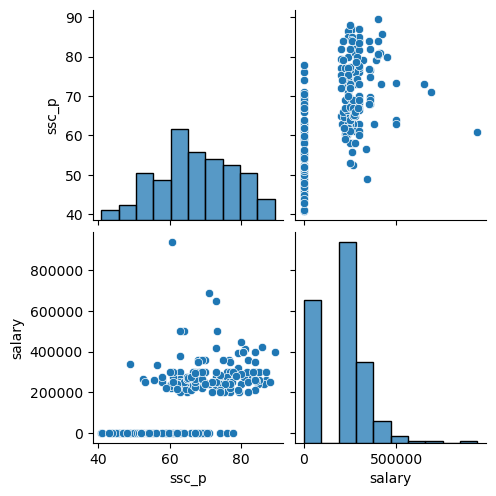

In [64]:
sns.pairplot(dataset[['ssc_p','salary']])

### From correlation matrix, ssc_p is comparitively highly correlated with salary